In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from STiMetaD import STiMetaD

: 

In [1]:
import pandas as pd
from pathlib import Path

proteins = ['chignolin', 'YYCPETGTWY', 'YYDPETGTWE', 'YYRPETGTWY', 'YYAPETGTWY', 'YYDPETGQWY', 'YYDPETGTWG', 'YYDPETGTWQ', 'YYNPETGTWY', 'YYEPETGTWY', 'YYDPETGTWR', 'YYDPETGVWY', 'YYDPETGYWY', 'YYDPETGTWV', 'YYDPETGRWY']

thresholds = np.arange(0.2, 0.50, 0.04)
all_mfpt = {protein: {th: [] for th in thresholds} for protein in proteins}


def read_colvar_with_fields(path):
    with open(path, "r") as f:
        header = f.readline().strip()
    parts = header.split()
    if len(parts) < 3 or parts[0] != "#!" or parts[1] != "FIELDS":
        raise ValueError(f"Unexpected FIELDS header in {path}: {header}")
    names = parts[2:]
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

for protein in proteins:
    base_path = Path(f"../data/{protein}/output")
    for i in range(5000, 5100):
        index_str = f"{i:03}"
        run_path = base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}"
        try:
            df = read_colvar_with_fields(run_path)
        except FileNotFoundError:
            print(f"Missing: {run_path}")
            continue
        if not {"time", "metad.acc", "rmsd"}.issubset(df.columns):
            print(f"Missing required columns in {run_path}")
            continue

        passed = set()
        for _, row in df.iterrows():
            time = row["time"]
            acc = row["metad.acc"]
            rmsd = row["rmsd"]
            predicted = time * acc
            for th in thresholds:
                if th not in passed and rmsd > th:
                    all_mfpt[protein][th].append(predicted)
                    passed.add(th)
            if len(passed) == len(thresholds):
                break



: 

In [4]:
import pickle

with open("../data/mfpt-pace=5000.pkl", "wb") as f:
    pickle.dump(all_mfpt, f)

In [1]:
# YYDPETGTWY

mutation_map = {
    "YYAPETGTWY": "D2A",
    "YYCPETGTWY": "D2C",
    "YYMPETGTWY": "D2M",
    "YYNPETGTWY": "D2N",
    "YYRPETGTWY": "D2R",
    "YYEPETGTWY": "D2E",
    "YYDPETGTWE": "Y9E",
    "YYDPETGTWG": "Y9G",
    "YYDPETGTWQ": "Y9Q",
    "YYDPETGTWR": "Y9R",
    "YYDPETGTWV": "Y9V",
    "YYDPETGTWA": "Y9A",
    "YYDPETGVWY": "T7V",
    "YYDPETGQWY": "T7Q",
    "YYDPETGRWY": "T7R",
    "YYDPETGYWY": "T7Y",
    "chignolin": "Wildtype"
}


groupByResidue = {
    2: ['D2A', 'D2C', 'D2M', 'D2N', 'D2R', 'D2E'], 
    7: ['T7V', 'T7Q', 'T7R', 'T7Y'], 
    9: ['Y9E', 'Y9G', 'Y9Q', 'Y9R', 'Y9V', 'Y9A']
}

groupByProperty = {
    "RHKDE": ["D2R", "D2E", "Y9E", "Y9R", "T7R"],
    "STNQ": ["D2N", "Y9Q", "T7Q"],
    "CUGP": ["D2C", "Y9G"],
    "AVILMFYW": ["D2A", "D2M", "Y9A", "Y9V", "T7V", "T7Y"],
}


In [1]:
from itertools import cycle
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from STiMetaD import STiMetaD
import numpy as np
import pickle

with open("../data/mfpt-pace=5000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)
    
estimator = STiMetaD(minSampleSize=10)
thresholds = np.arange(0.2, 0.50, 0.04)
short_to_residue = {short: idx for idx, shorts in groupByResidue.items() for short in shorts}
short_to_property = {short: prop for prop, shorts in groupByProperty.items() for short in shorts}

data = pd.read_csv('../data/eigenvalues.csv', index_col='mutation')
wt_eigenvalue = data.loc['Wildtype', 'eigenvalue']

def collect_df(th: float, sample_size: int):
    rows = []
    # chignolin mean MFPT (for the horiz line)
    chig_sorted = np.array(all_mfpt['chignolin'][th])[:sample_size]
    chig_mfpt = estimator.estimateMFPT(chig_sorted)

    for long_name in proteins:
        short = mutation_map.get(long_name)
        if short is None:
            raise ValueError(f"Unknown mutation: {long_name}")
        s = np.array(all_mfpt[long_name][th])[:sample_size]
        mfpt = estimator.estimateMFPT(s)
        print(f"{long_name} ({short}): {(mfpt * 1e-6):.3g} us")
        x = np.log(wt_eigenvalue / data.loc[short, "eigenvalue"])
        y = np.log(chig_mfpt / mfpt) 

        rows.append({
            "long": long_name,
            "short": short,
            "x": x,
            "y": y,
            "residue_idx": short_to_residue.get(short),        # 2/7/9 or None
            "property_grp": short_to_property.get(short),      # "RHKDE"/... or None
        })

    df = pd.DataFrame(rows)
    return df, chig_mfpt

def color_map(keys):
    # stable color cycle
    base = cycle(plt.rcParams['axes.prop_cycle'].by_key().get('color', []))
    return {k: next(base) for k in keys}

sample_size = 100
th = thresholds[4]

df, chig_mfpt = collect_df(th, sample_size)

# quick correlations
pearson, _ = stats.pearsonr(df["x"], df["y"])
spearman, _ = stats.spearmanr(df["x"], df["y"])

: 

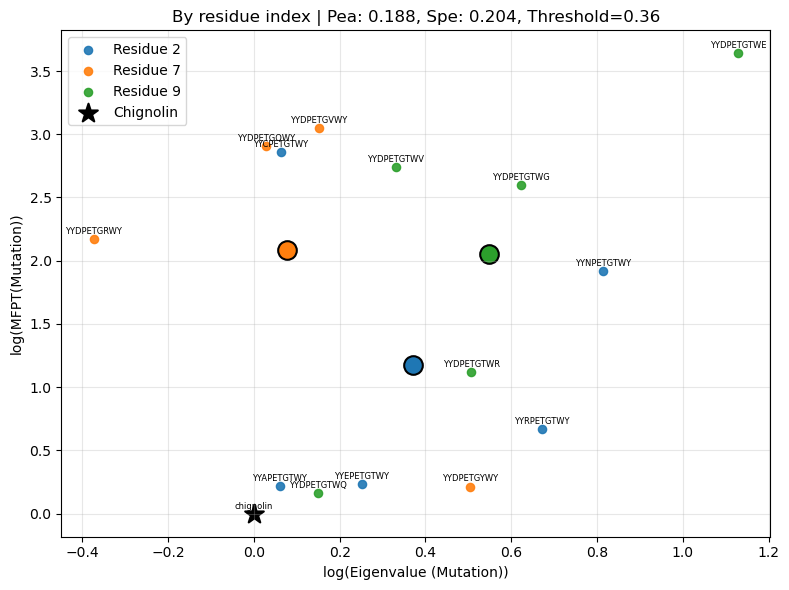

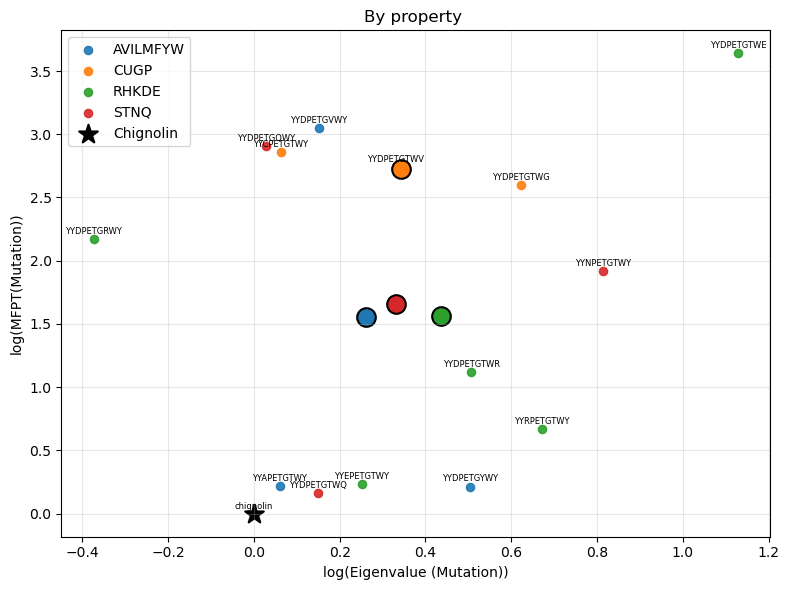


Property-group means:
                     x         y
property_grp                    
AVILMFYW      0.261492  1.555748
CUGP          0.342627  2.728065
RHKDE         0.436824  1.565948
STNQ          0.330821  1.660658

Residue-index means:
                    x         y
residue_idx                    
2.0          0.371980  1.178414
7.0          0.077328  2.085924
9.0          0.547718  2.051014


In [105]:
prop_keys = sorted([k for k in df["property_grp"].dropna().unique()])
prop_colors = color_map(prop_keys)

res_keys = sorted([int(k) for k in df["residue_idx"].dropna().unique()])
res_colors = color_map(res_keys)

plt.figure(figsize=(8, 6))
for k in res_keys:
    sub = df[df["residue_idx"] == k]
    plt.scatter(sub["x"], sub["y"], label=f"Residue {k}", alpha=0.9, s=35, c=res_colors[k])

for _, r in df.iterrows():
    plt.text(r["x"], r["y"] + 0.06, r["long"], fontsize=6, ha='center', va='center')

if not chig_row.empty:
    chig_res = chig_row.iloc[0]["residue_idx"]
    chig_color = res_colors.get(chig_res, "black")
    plt.scatter(chig_row["x"], chig_row["y"], s=200, marker='*', c=chig_color,
                edgecolors='k', linewidths=1.5, label="Chignolin")

res_means = df.dropna(subset=["residue_idx"]).groupby("residue_idx")[["x", "y"]].mean()
for k in res_means.index:
    plt.scatter(res_means.loc[k, "x"], res_means.loc[k, "y"], s=180,
                facecolors=res_colors[k], edgecolors='k', linewidths=1.5, )

plt.xlabel('log(Eigenvalue (Mutation))')
plt.ylabel('log(MFPT(Mutation))')
plt.title(f"By residue index | Pea: {pearson:.3g}, Spe: {spearman:.3g}, Threshold={th:.3g}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for k in prop_keys:
    sub = df[df["property_grp"] == k]
    plt.scatter(sub["x"], sub["y"], label=k, alpha=0.9, s=35, c=prop_colors[k])

for _, r in df.iterrows():
    plt.text(r["x"], r["y"] + 0.06, r["long"], fontsize=6, ha='center', va='center')

chig_row = df[df["short"] == "Wildtype"]
if not chig_row.empty:
    chig_prop = chig_row.iloc[0]["property_grp"]
    chig_color = prop_colors.get(chig_prop, "black")
    plt.scatter(chig_row["x"], chig_row["y"], s=200, marker='*', c=chig_color,
                edgecolors='k', linewidths=1.5, label="Chignolin")

prop_means = df.dropna(subset=["property_grp"]).groupby("property_grp")[["x", "y"]].mean()
for k in prop_means.index:
    plt.scatter(prop_means.loc[k, "x"], prop_means.loc[k, "y"], s=180,
                facecolors=prop_colors[k], edgecolors='k', linewidths=1.5)

plt.xlabel('log(Eigenvalue (Mutation))')
plt.ylabel('log(MFPT(Mutation))')
plt.title(f"By property ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nProperty-group means:")
print(prop_means.sort_index())
print("\nResidue-index means:")
print(res_means.sort_index())


In [72]:


def fit_exp_ks(samples):
    x = np.array(samples)
    x.sort()

    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau): return 1 - np.exp(-t / tau)
    
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    D, p = stats.kstest(x, "expon", args=(0, tau))
    return tau, p, D
    
def obtainEstimationsDataFrame(samples, minSampleSize):


    samples.sort()

    survival = np.array(
        [(len(samples) - i) / len(samples) for i in range(len(samples))]
    )
    predictions = []
    R2s: list[Unknown] = []
    limits: int = []
    for limit in range(minSampleSize, len(samples)):
        firstSamples = samples[:limit]
        k = -sum(firstSamples* np.log(survival[:limit])) / sum(
            firstSamples ** 2
        )
        predictions.append(k)
        R2s.append(
            1
            - sum((np.log(survival[:limit]) + k * firstSamples) ** 2)
            / sum((np.log(survival[:limit]) - np.log(survival[:limit]).mean()) ** 2)
        )
        limits.append(limit)

    return pd.DataFrame(
        {"Tstar": samples[minSampleSize:], "prediction": predictions, "R2": R2s, "limit": limits}
    )
    
def estimateMFPT(samples, minSampleSize=5):
    """
    Estimates the mean first-passage time.
    """

    data = obtainEstimationsDataFrame(
        samples=samples, minSampleSize=minSampleSize
    )
    max = data.loc[data.R2 == data.R2.max()]
    limit = max.limit

    return float(1 / max.prediction), int(limit)

/tmp/ipykernel_232887/78441859.py:52: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)
/tmp/ipykernel_232887/78441859.py:52: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)


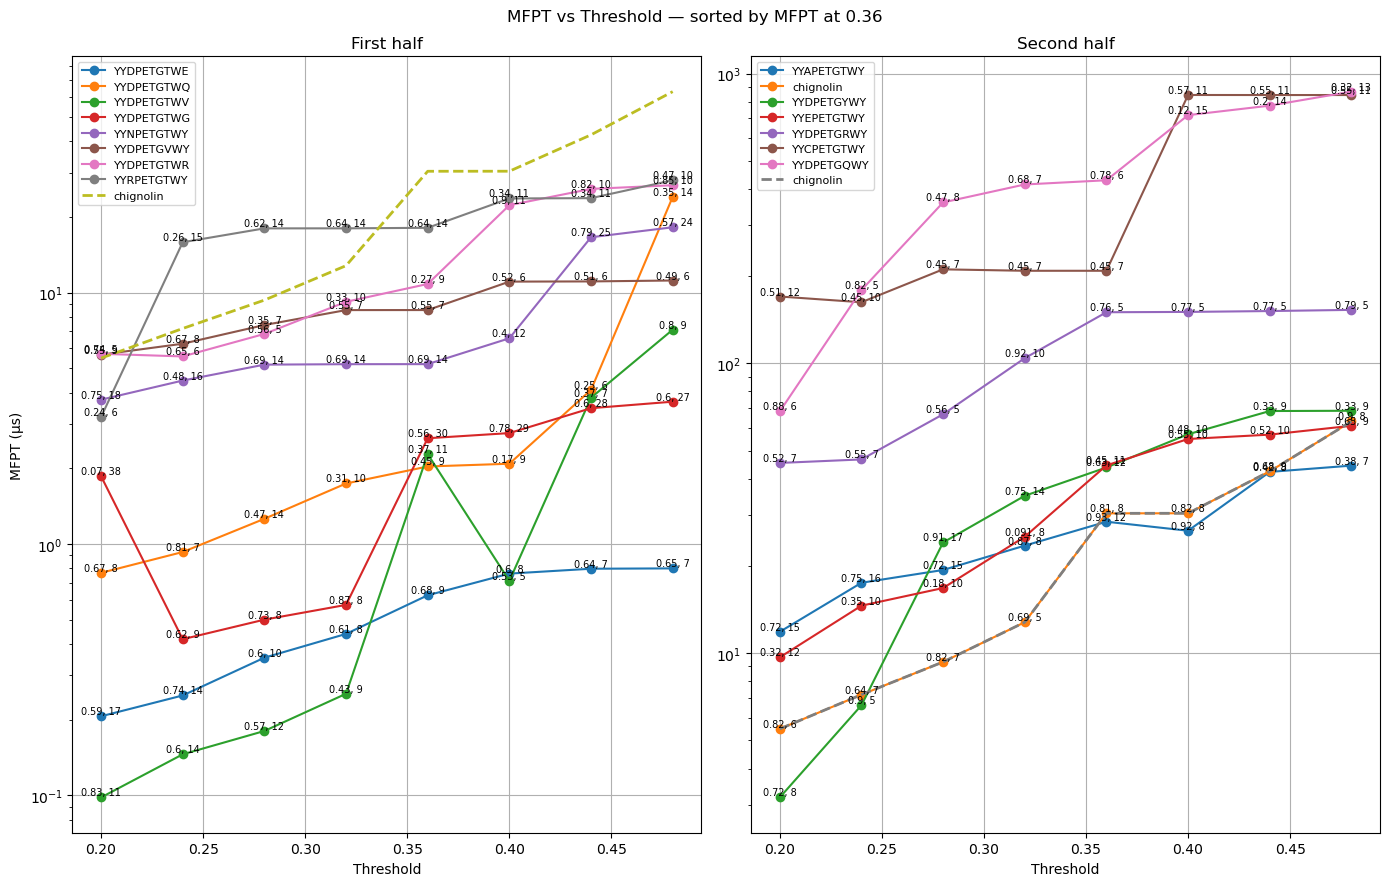

['YYDPETGTWE',
 'YYDPETGTWQ',
 'YYDPETGTWV',
 'YYDPETGTWG',
 'YYNPETGTWY',
 'YYDPETGVWY',
 'YYDPETGTWR',
 'YYRPETGTWY',
 'YYAPETGTWY',
 'chignolin',
 'YYDPETGYWY',
 'YYEPETGTWY',
 'YYDPETGRWY',
 'YYCPETGTWY',
 'YYDPETGQWY']

In [73]:


def plot_all_mfpt(all_mfpt, proteins, thresholds, sort_idx=4):
    """
    Sort proteins by ascending MFPT at thresholds[sort_idx] and plot side-by-side
    with independent y-scales and legends.
    """
    sort_idx = max(0, min(sort_idx, len(thresholds) - 1))

    # Collect MFPT (µs)
    series = {p: [] for p in proteins}
    pValues = {p: [] for p in proteins}
    chig = []

    for th in thresholds:
        s = np.sort(np.array(all_mfpt['chignolin'][th]))
        chig_mfpt, lim = estimateMFPT(s)
        chig.append(chig_mfpt / 1e6)

        for p in proteins:
            s = np.sort(np.array(all_mfpt[p][th]))
            mfpt, lim = estimateMFPT(s)
            series[p].append(mfpt / 1e6)
            tau, pValue, D = fit_exp_ks(s[:lim])

            pValues[p].append((pValue, lim))

    def sort_key(p):
        return series[p][sort_idx]

    proteins_sorted = sorted(proteins, key=sort_key)

    mid = (len(proteins_sorted) + 1) // 2
    halves = [proteins_sorted[:mid], proteins_sorted[mid:]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharey=False)
    ref_th = thresholds[sort_idx]

    for ax, subset, title_suffix in zip(axes, halves, ['First half', 'Second half']):
        for p in subset:
            ax.plot(thresholds, series[p], marker='o', label=p)

            for x, y, (p, lim) in zip(thresholds,series[p], pValues[p]):
                ax.text(x, y, f"{p:.2g}, {lim}", ha='center', va='bottom', fontsize=7)

        ax.plot(thresholds, chig, linestyle='--', linewidth=2, label='chignolin')
        ax.set_xlabel('Threshold')
        ax.set_title(f'{title_suffix}')
        ax.set_yscale('log')
        ax.legend(fontsize=8, ncol=1)
        ax.grid(True)

    axes[0].set_ylabel('MFPT (µs)')
    fig.suptitle(f'MFPT vs Threshold — sorted by MFPT at {ref_th:.3g}')

    plt.tight_layout()
    plt.show()

    return proteins_sorted

plot_all_mfpt(all_mfpt, proteins, thresholds)


      name  n          tau     ks_p     ks_D
 chignolin 15 3.131158e+06 0.939216 0.128301
YYAPETGTWY 15 2.417486e+06 0.912639 0.135266
YYDPETGTWR 15 1.078527e+06 0.816394 0.154235
YYNPETGTWY 15 4.012422e+05 0.778681 0.160485
YYDPETGYWY 15 3.682189e+06 0.710115 0.171189
YYDPETGRWY 15 2.522686e+07 0.708221 0.171477
YYEPETGTWY 15 3.929473e+06 0.672194 0.176936
YYRPETGTWY 15 1.300171e+06 0.638097 0.182081
YYDPETGTWE 15 6.751477e+04 0.565397 0.193184
YYCPETGTWY 15 3.928671e+07 0.467516 0.208896
YYDPETGTWV 15 2.030117e+05 0.443895 0.212898
YYDPETGTWG 15 1.167021e+05 0.290934 0.242561
YYDPETGTWQ 15 2.328552e+05 0.190388 0.268747
YYDPETGQWY 15 4.571724e+07 0.153240 0.281139
YYDPETGVWY 15 2.919859e+06 0.118737 0.295006


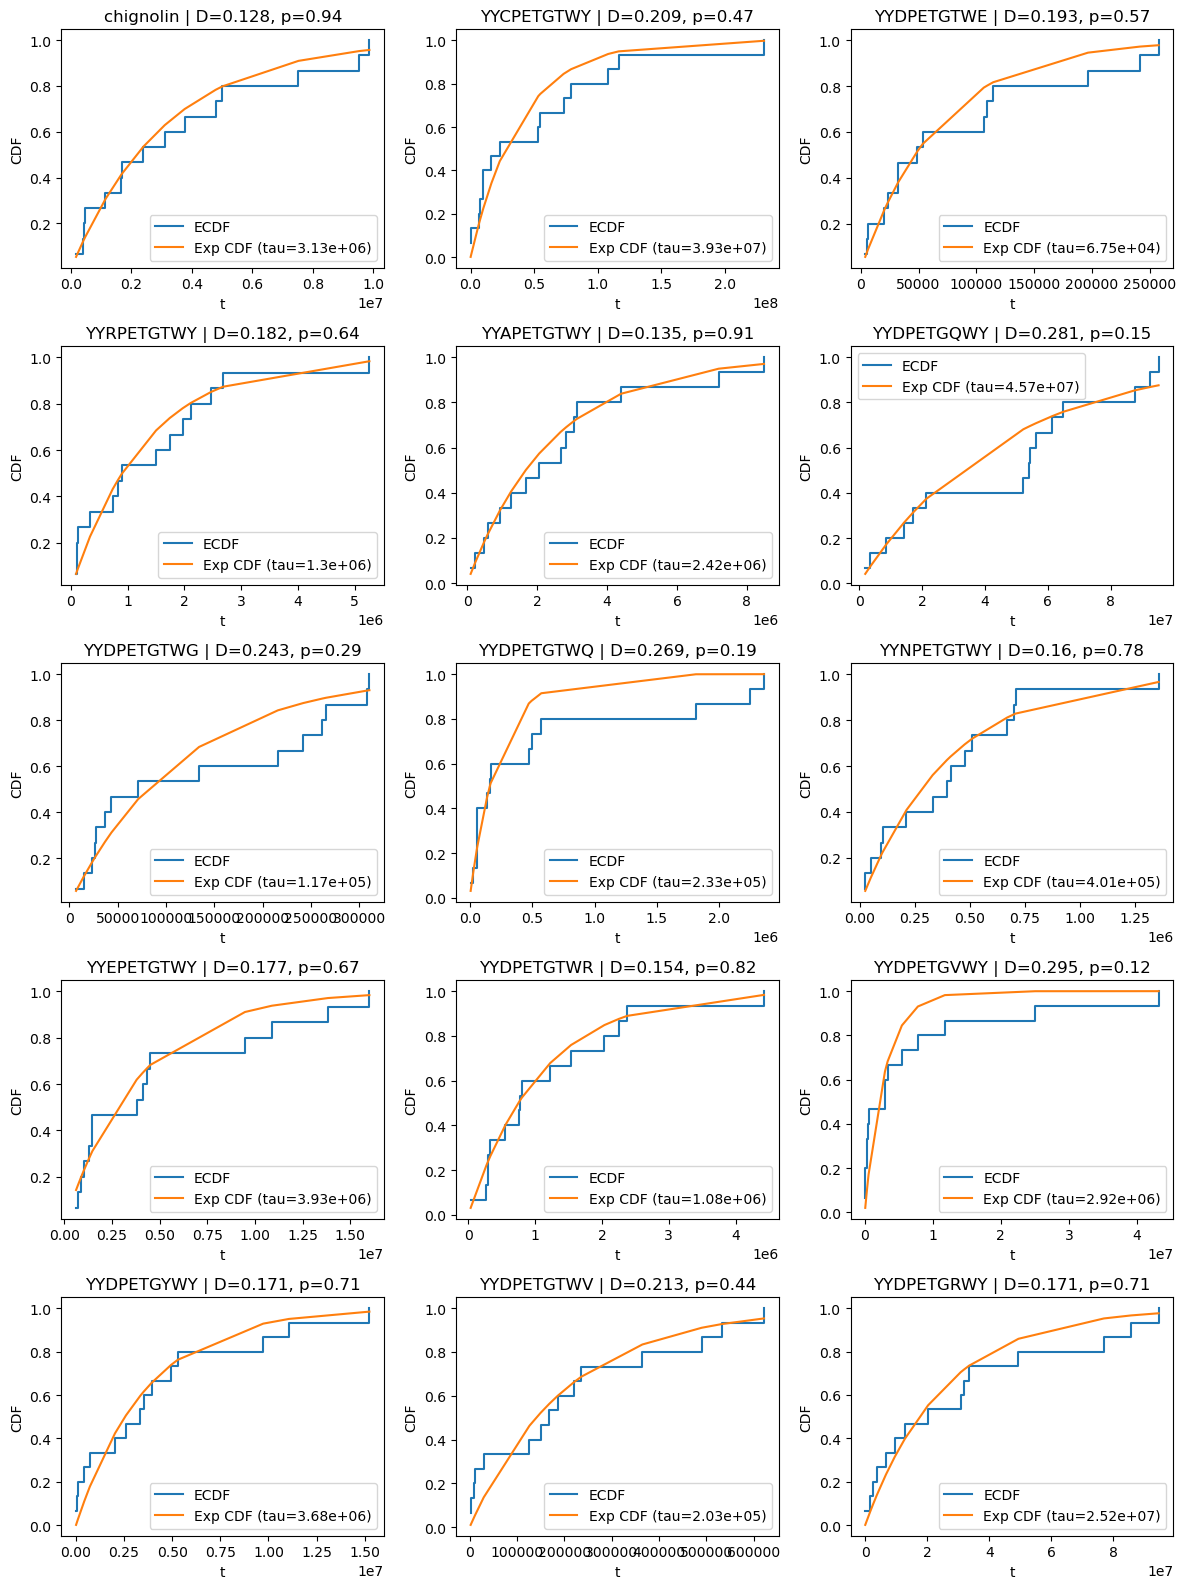

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
import math

def fit_exp_ks(samples):
    x = np.array(samples)
    x.sort()

    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau): return 1 - np.exp(-t / tau)
    
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    D, p = stats.kstest(x, "expon", args=(0, tau))
    return tau, p, D

def fit_exp_ecdf(samples, ax):
    x = np.array(samples)

    n = x.size
    def F(t, tau): return 1 - np.exp(-t / tau)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)

    ax.step(x, ecdf, where="post", label="ECDF")
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})")
    D, p = stats.kstest(x, "expon", args=(0, tau))
    ax.set_xlabel("t"); ax.set_ylabel("CDF"); ax.legend(); ax.set_title(f"D={D:.3g}, p={p:.2g}")
    return tau, D, p, ax

def ks_table_fastest_k(all_mfpt, names, th, k):
    rows = []
    for name in names:
        s = np.array(all_mfpt[name][th])
        s.sort()
        
        s = s[:k]
        tau, p, D = fit_exp_ks(s)
        rows.append({"name": name, "n": s.size, "tau": tau, "ks_p": p, "ks_D": D})
    return pd.DataFrame(rows).sort_values("ks_p", ascending=False)

def plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k, ncols=3):
    m = len(names)
    nrows = math.ceil(m / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), squeeze=False)
    for i, name in enumerate(names):
        r, c = divmod(i, ncols)
        s = np.sort(np.array(all_mfpt[name][th]))[:k]
        fit_exp_ecdf(s, ax=axes[r, c])
        axes[r, c].set_title(f"{name} | " + axes[r, c].get_title())
        
  
    fig.tight_layout()
    return fig

th = thresholds[4]
names = list(proteins)
k = 15
res = ks_table_fastest_k(all_mfpt, names, th, k=k)
print(res.to_string(index=False))
fig = plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k=k, ncols=3)
plt.show()
